# Simon's Algorithm
The oracle hides a period $s$ with $f(x)=f(x\oplus s)$ (a 2-to-1 function). Unlike Deutsch-Jozsa / Bernstein-Vazirani, one run isn't enough:
each measurement returns a $y$ satisfying $y\cdot s = 0 \bmod 2$. Collect many $y$'s, then classically recover $s$.
Run twice — an ideal simulator and a noisy one carrying a real IBM device's noise model (offline).

In [1]:
# Oracle: copy input->output (makes it 2-to-1), then imprint the period s
from qiskit import QuantumCircuit

def simon_oracle(s: str) -> QuantumCircuit:
    n = len(s)
    oracle = QuantumCircuit(2 * n)
    for i in range(n):
        oracle.cx(i, n + i)                 # copy input register into output register
    idx = [i for i, b in enumerate(reversed(s)) if b == "1"]
    if idx:
        j = idx[0]                          # control on the lowest set bit of s
        for i in idx:
            oracle.cx(j, n + i)
    return oracle

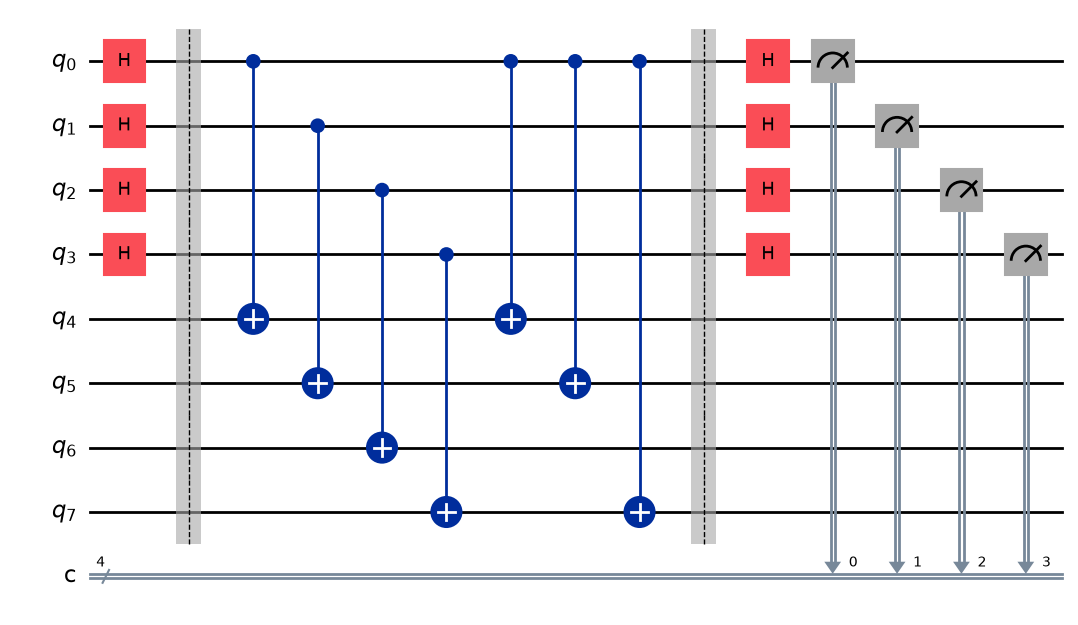

In [2]:
# Assemble the full Simon circuit (2n qubits, measure only the input register) and draw it
s = "1011"                       # the secret period to recover
n = len(s)

qc = QuantumCircuit(2 * n, n)
qc.h(range(n))                   # superposition over all inputs
qc.barrier()
qc.compose(simon_oracle(s), inplace=True)
qc.barrier()
qc.h(range(n))                   # interference: each outcome y obeys y.s = 0
qc.measure(range(n), range(n))

qc.draw("mpl")

In [3]:
# Run on an ideal simulator and a noisy one (FakeSherbrooke = real IBM device noise model, offline)
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

ideal = AerSimulator()
noisy = AerSimulator.from_backend(FakeSherbrooke())

counts_ideal = ideal.run(transpile(qc, ideal), shots=1024).result().get_counts()
counts_noisy = noisy.run(transpile(qc, noisy, optimization_level=3), shots=1024).result().get_counts()

In [4]:
# Classical post-processing: pick the nonzero s that the most shots agree with (y.s = 0).
# Count-weighted, so it survives the wrong bitstrings that noise injects.
def recover_s(counts, n):
    best_s, best_score = None, -1
    for cand in range(1, 2 ** n):
        s = format(cand, f"0{n}b")
        score = sum(c for y, c in counts.items()
                    if sum(int(a) & int(b) for a, b in zip(y, s)) % 2 == 0)
        if score > best_score:
            best_s, best_score = s, score
    return best_s

secret s        : 1011
ideal recovered : 1011
noisy recovered : 1011


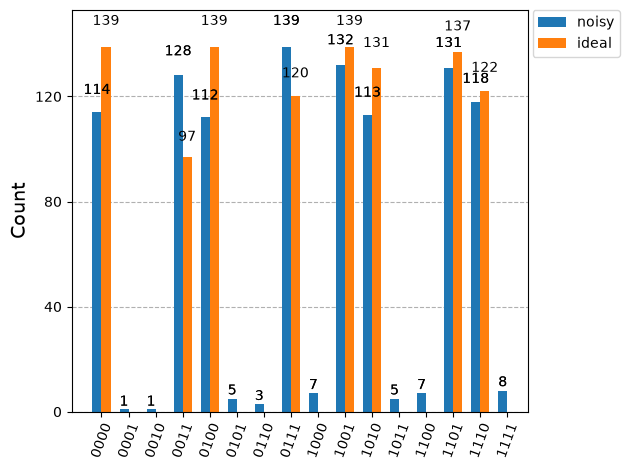

In [5]:
# Recover s from both runs and show the histograms
from qiskit.visualization import plot_histogram

print("secret s        :", s)
print("ideal recovered :", recover_s(counts_ideal, n))
print("noisy recovered :", recover_s(counts_noisy, n))
plot_histogram([counts_noisy, counts_ideal], legend=["noisy", "ideal"])